In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import PIL
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, random_split

In [34]:
train_data_dir = '../sign_lang_recognition/data/sign_mnist_train.csv'
test_data_dir = '../sign_lang_recognition/data/sign_mnist_test.csv'

In [35]:
class SignLanguageMNIST(torch.utils.data.Dataset):
    def __init__(self, csv_file, label_map, transform=None):
        self.data = pd.read_csv(csv_file)
        self.labels = self.data['label'].map(label_map).values
        # If not account for missing 2 classes
        # self.labels = self.data['label'].values
        
        # 784 pixel columns, so 28x28 with 1 channel (grayscale)
        pixels = self.data.drop('label', axis=1).values
        self.images = pixels.reshape(-1, 28, 28, 1).astype(np.uint8)
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
    
to_tensor = transforms.ToTensor()

train_df = pd.read_csv(train_data_dir)
label_map = {l:i for i,l in enumerate(sorted(train_df['label'].unique()))}

train_tensor = SignLanguageMNIST(csv_file=train_data_dir, label_map=label_map, transform=to_tensor)
test_tensor = SignLanguageMNIST(csv_file=test_data_dir, label_map=label_map, transform=to_tensor)

Verifying the number of classes given the description that there are no cases for 9=J or 25=Z because of gesture motions.

In [36]:
print("Number of unique labels in training set:", pd.Series(train_tensor.labels).nunique())
#print("The Classes not on here:", set(range(26)) - set(pd.Series(train_tensor.labels).unique()))
#print(pd.Series(train_tensor.labels).value_counts())

Number of unique labels in training set: 24


In [37]:
train_img = torch.stack([img for img, _ in train_tensor])

train_mean = train_img.view(1,-1).mean(dim=1)
train_std = train_img.view(1,-1).std(dim=1)

valid_img = torch.stack([img for img, _ in test_tensor])
valid_mean = valid_img.view(1,-1).mean(dim=1)
valid_std = valid_img.view(1,-1).std(dim=1)

# Reload the Datasets with the normalization transforms
transformed_train_tensor = SignLanguageMNIST(
    csv_file=train_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(train_mean, train_std)
    ])
)

transformed_test_tensor = SignLanguageMNIST(
    csv_file=test_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(valid_mean, valid_std)])
)

transformed_test_tensor_norm_w_train = SignLanguageMNIST(
    csv_file=test_data_dir, 
    label_map=label_map,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(train_mean, train_std)])
)

In [38]:
train_size = int(0.8 * len(transformed_train_tensor))
val_size = len(transformed_train_tensor) - train_size

train_subset, val_subset = random_split(
    transformed_train_tensor, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

To avoid data leakage, the test set must be normalized using the mean and standard deviation derived strictly from the training set. This ensures the model treats unseen data as it would in a real-world scenario. So trying an interation with the test data normalized using the train mean and standard deviation.

In [39]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(transformed_test_tensor, batch_size=64, shuffle=False)
test_loader_norm_w_train = DataLoader(transformed_test_tensor_norm_w_train, batch_size=64, shuffle=False)

In [40]:
def train_model(n_epochs, model, optimizer, loss_fn, train_loader, val_loader):
    log_data = [] 
    
    for epoch in range(1, n_epochs + 1):
        model.train() 
        epoch_train_loss = 0.0
        train_correct, train_total = 0, 0
        for imgs, labels in train_loader:
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            predicted = preds.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval() 
        epoch_val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad(): 
            for imgs, labels in val_loader: 
                preds = model(imgs)
                loss = loss_fn(preds, labels)
                epoch_val_loss += loss.item()
                predicted = preds.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        log_data.append({
            'epoch': epoch,
            'train_loss': epoch_train_loss / len(train_loader),
            'validation_loss': epoch_val_loss / len(val_loader),
            'train_accuracy': train_correct / train_total,
            'validation_accuracy': val_correct / val_total,
            'learning_rate': optimizer.param_groups[0]['lr']
        })
    return pd.DataFrame(log_data)

In [41]:
mlp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 24)
)

adam_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [42]:
mlp_log = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model, 
                      train_loader=train_loader, 
                      val_loader=val_loader)


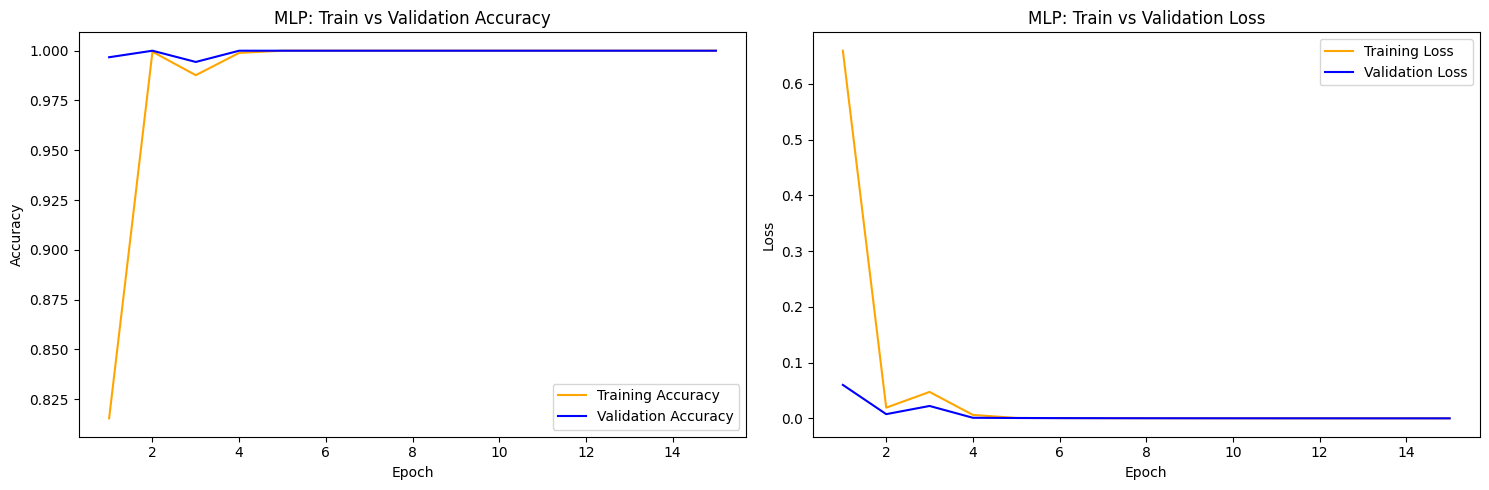

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log['epoch'], mlp_log['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log['epoch'], mlp_log['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log['epoch'], mlp_log['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log['epoch'], mlp_log['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Based on the graphs, the model is performing well with accuracy converging to approximately 1 after only 2 epochs. Would reducing the complexity impact this a lot? Could complexity be reduced to avoid potential overfitting?

In [56]:
mlp_model_small = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 24)
)

small_adam_optimizer = torch.optim.Adam(mlp_model_small.parameters(), lr=0.001)

mlp_log_small = train_model(n_epochs=15, 
                      optimizer=small_adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_small, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

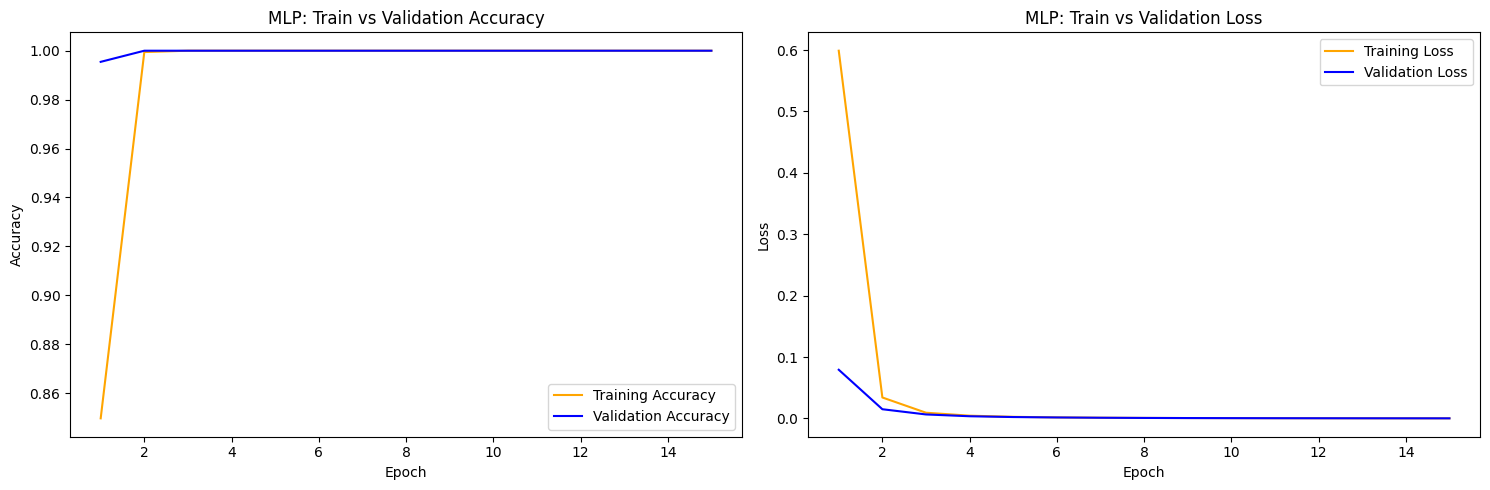

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(mlp_log_small['epoch'], mlp_log_small['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_small['epoch'], mlp_log_small['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('MLP: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_small['epoch'], mlp_log_small['train_loss'], color='orange', label='Training Loss')
axes[1].plot(mlp_log_small['epoch'], mlp_log_small['validation_loss'], color='blue', label='Validation Loss')
axes[1].set_title('MLP: Train vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Based on the results, it seems like a smaller network with just two layers have a similar performance. Would drop out impact performance or could it be another potential way to avoid overfitting?

In [59]:
p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
grid_search_results = []

for p in p_values:
    current_model = nn.Sequential(
        nn.Flatten(),                 
        nn.Linear(784, 256),        
        nn.ReLU(),
        nn.Dropout(p=p),
        nn.Linear(256, 24)            
    )
    current_optimizer = torch.optim.Adam(current_model.parameters(), lr=0.001)
    
    log_df = train_model(n_epochs=5, 
                         model=current_model, 
                         optimizer=current_optimizer,
                         loss_fn=nn.CrossEntropyLoss(),
                         train_loader=train_loader, 
                         val_loader=val_loader)
    
    final_train_acc = log_df['train_accuracy'].iloc[-1]
    final_val_acc = log_df['validation_accuracy'].iloc[-1]
    
    grid_search_results.append({
        'p_value': p,
        'final_train_accuracy': final_train_acc,
        'final_validation_accuracy': final_val_acc
    })

results_df = pd.DataFrame(grid_search_results)
best_results = results_df.sort_values(by='final_validation_accuracy', ascending=False)

print("\n=== Grid Search Results ===")
print(best_results)


=== Grid Search Results ===
   p_value  final_train_accuracy  final_validation_accuracy
0      0.1              0.999909                   1.000000
4      0.5              0.982244                   0.999818
2      0.3              0.990029                   0.998725
3      0.4              0.992897                   0.997815
1      0.2              0.988390                   0.993444
